# Spectral Data prep

Whether conducting statistical analyses or analysing separability, raw spectral refectance data should be prepared before ingesting into the `spectral_separability.ipynb` or `spectral_stats.ipynb`. This notebook walks through the various data preparation steps available in this repo.

1. Data Labelling - make new labels based on existing classifications
2. Cropping noisy wavelengths - cut down spectral range extremities to highest SNR region
3. Normalize data - Normalize all data to the range 0-1 (MinMax) or 0 mean and 1 st.dev (Standard Scaler)
4. Filter to targets - Reduce sample set to targets of interest
5. Denoise spectra - Use wavelet decomposition to remove high frequency noise
6. Resample spectra - Use Relative Spectral Responses from locally stored files to simulate other sensors

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import auxiliary.preprocessing as prep
import auxiliary.hyper_denoiser as hyper_denoiser
import auxiliary.resampling as resamp
import auxiliary.tools as tools

In [16]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Define preprocessing parameters for hyperspectral data
full_res_path = "data/raw/MEL_NZ_TAS_spectra.csv"
bad_bands_list = list(map(str,(range(753, 769))))
bad_bands_treatment = "interpolate"
scaler = "minmax"
target_scheme = "all"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [18]:
# Initialize the preprocessing class (hyperspectral data only)
prepper = prep.PreprocessRefl(data_path = full_res_path,
                              bad_bands = bad_bands_list,
                              bad_bands_treatment= bad_bands_treatment,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)

In [19]:
prepper.import_data()
prepper.make_new_labels()
prepper.spectra, prepper.labels = tools.sort_classes(prepper.spectra, prepper.labels,  labels_col = "Class")
prepper.filter_targets()
prepper.crop_noisy_wavelengths()

data = prepper.spectra_reduc
labels = prepper.labels_filtered

Data filtered from 388 to 388 spectra.


In [20]:
labels.to_csv("./data/labels_prepped.csv")

# Denoising

Before picking your level of noise to remove, it is smart to check out a few different levels to make sure the useful information in the signal is being preserved.
Use the plotting function below to compare noise removal levels, then calculate it for the whole dataset when you are satisfied.

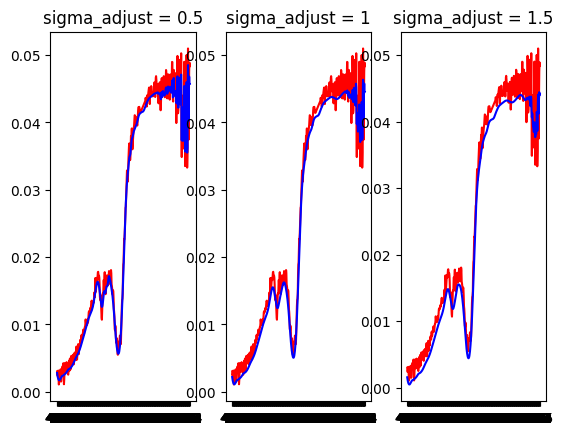

In [21]:
# Pick a sample to investigate and sigma adjustments to try (higher=more smoothing)
sample = 204

sigmas_levels = [0.5, 1, 1.5]
data = data.dropna(axis = 1)


# Plot the chosen samples denoised with the indicated sigma adjustments
fig, ax = plt.subplots(1,3)
ax[0].plot(data.iloc[sample, :].dropna(), color = "red")
ax[0].plot(pd.DataFrame(hyper_denoiser.denoise_spectrum(spectrum = data.iloc[sample, :], sigma_adjust=sigmas_levels[0])).set_index(data.columns), color = "blue")
ax[0].set_title(f"sigma_adjust = {sigmas_levels[0]}")

ax[1].plot(data.iloc[sample, :].dropna(), color = "red")
ax[1].plot(pd.DataFrame(hyper_denoiser.denoise_spectrum(spectrum = data.iloc[sample, :], sigma_adjust=sigmas_levels[1])).set_index(data.columns), color = "blue")
ax[1].set_title(f"sigma_adjust = {sigmas_levels[1]}")

ax[2].plot(data.iloc[sample, :].dropna(), color = "red")
ax[2].plot(pd.DataFrame(hyper_denoiser.denoise_spectrum(spectrum = data.iloc[sample, :], sigma_adjust=sigmas_levels[2])).set_index(data.columns), color = "blue")
ax[2].set_title(f"sigma_adjust = {sigmas_levels[2]}")

plt.show()

In [22]:
sigma_adjust = 0.5
quiet_data = pd.DataFrame(index = data.index, columns = data.columns)

for row in range(data.shape[0]):
    spectrum = data.iloc[row, :].dropna()
    quiet_data.iloc[row, :] = hyper_denoiser.denoise_spectrum(spectrum, sigma_adjust = sigma_adjust)

# Normalize 



In [27]:
# If you want to use de-noised data, uncomment the next line
prepper.spectra_reduc = quiet_data
prepper.normalize_data()
data = prepper.spectra_norm

In [28]:
#Adjust export name and location as desired
data.to_csv("quiet_prepped_data_fullres.csv", index = True)


## __________________________________________________________________________________________________________________________________________________________
##
# 📡 Resample to satellite sensors

Spectrally resample the dataset to match the relative spectral response (RSR) functions of satellite sensors. Can be implemented for a single sensor at a time or as a batch application to all available RSRs in a directory

In cases where there is only a small overlap between the destination RSR and the existing spectral data, the resampled output may be inaccurately low. To avoid this, use the `minimum_response_trim` function to limit to destination bands that hve good coverage of your data. For example, setting the parameter to `0.1` will only output destination bands in which at least 10% of their relative spectral response is in the spectral range of your data.

In [25]:
funcs = resamp.get_rsr_functions(rsr_dir='satellite_RSRs/')

In [26]:
resamp.resample_to_all(rsr_dir = "satellite_RSRs/", spectra = data, out_dir= "data/processed/resampled/", minimum_response_trim= 0.1)

Dictionary contents: ['Dove', 'Enmap', 'Landsat_9', 'Sentinel_2_ABC', 'Skysat', 'Superdove']
About to iterate over 6 items
Resampling to Dove...
Resampling data to 4 bands
Resampled data for Dove saved to data/processed/resampled/Dove_resampled.csv
Resampling to Enmap...
Resampling data to 78 bands
Resampled data for Enmap saved to data/processed/resampled/Enmap_resampled.csv
Resampling to Landsat_9...
Resampling data to 5 bands
Resampled data for Landsat_9 saved to data/processed/resampled/Landsat_9_resampled.csv
Resampling to Sentinel_2_ABC...
Resampling data to 8 bands
Resampled data for Sentinel_2_ABC saved to data/processed/resampled/Sentinel_2_ABC_resampled.csv
Resampling to Skysat...
Resampling data to 5 bands
Resampled data for Skysat saved to data/processed/resampled/Skysat_resampled.csv
Resampling to Superdove...
Resampling data to 7 bands
Resampled data for Superdove saved to data/processed/resampled/Superdove_resampled.csv
Successfully saved resampled data for Dove_resample